# lazymerge demo

Lazily merge geospatial Zarr arrays across CRS boundaries using Cubed.

This notebook creates synthetic source arrays in two different UTM zones (EPSG:32618 and EPSG:32617),
merges them into a single target grid, and visualizes the result with xarray.

**Extra dependencies:** This notebook requires `xarray`, `matplotlib`, and `rasterix` for visualization.

```
uv pip install xarray matplotlib rasterix
```

In [1]:
import numpy as np
import xarray as xr
import zarr
from affine import Affine
from rasterix import RasterIndex

from lazymerge.conventions import (
    ProjAttrs,
    SpatialAttrs,
    read_proj,
    read_spatial,
    write_proj,
    write_spatial,
)
from lazymerge.merge import merge
from lazymerge.sources import scan_store
from lazymerge.target import create_target, to_zarr

## 1. Create synthetic source arrays

Four tiles arranged in a 2x2 grid. The left two tiles are in **UTM 18N** (EPSG:32618),
and the right two are in **UTM 17N** (EPSG:32617) — covering adjacent geographic areas
but stored in different coordinate reference systems.

In [2]:
store = zarr.storage.MemoryStore()
root = zarr.open_group(store, mode="w")

sources = [
    # UTM 18N tiles (left side)
    {
        "name": "utm18n_tile_a",
        "crs": "EPSG:32618",
        "bbox": (500000.0, 5990000.0, 505000.0, 5995000.0),
        "resolution": 10.0,
        "fill": 100.0,
    },
    {
        "name": "utm18n_tile_c",
        "crs": "EPSG:32618",
        "bbox": (500000.0, 5995000.0, 505000.0, 6000000.0),
        "resolution": 10.0,
        "fill": 300.0,
    },
    # UTM 17N tiles (right side — same geographic area as UTM 18N
    # x=[503000, 508000], but expressed in UTM zone 17N coordinates)
    {
        "name": "utm17n_tile_b",
        "crs": "EPSG:32617",
        "bbox": (895094.0, 6006920.0, 900511.0, 6012337.0),
        "resolution": 10.0,
        "fill": 200.0,
    },
    {
        "name": "utm17n_tile_d",
        "crs": "EPSG:32617",
        "bbox": (894669.0, 6011912.0, 900086.0, 6017329.0),
        "resolution": 10.0,
        "fill": 400.0,
    },
]

for src in sources:
    xmin, ymin, xmax, ymax = src["bbox"]
    res = src["resolution"]
    width = int((xmax - xmin) / res)
    height = int((ymax - ymin) / res)

    arr = root.create_array(src["name"], shape=(height, width), dtype="f4", chunks=(256, 256))
    arr[:] = src["fill"]

    write_spatial(
        arr,
        SpatialAttrs(
            dimensions=["y", "x"],
            transform=(res, 0.0, xmin, 0.0, -res, ymax),
            bbox=(xmin, ymin, xmax, ymax),
            shape=(height, width),
        ),
    )
    write_proj(arr, ProjAttrs(code=src["crs"]))
    print(f"{src['name']}: shape=({height}, {width}), crs={src['crs']}, fill={src['fill']}")

utm18n_tile_a: shape=(500, 500), crs=EPSG:32618, fill=100.0
utm18n_tile_c: shape=(500, 500), crs=EPSG:32618, fill=300.0
utm17n_tile_b: shape=(541, 541), crs=EPSG:32617, fill=200.0
utm17n_tile_d: shape=(541, 541), crs=EPSG:32617, fill=400.0


## 2. Build source index

`scan_store` walks the Zarr group, reads `spatial:` and `proj:` convention attributes
from each array, and builds a spatial index for fast intersection queries.

In [3]:
index = scan_store(root)
print(f"Found {len(index.entries)} source arrays:\n")
for entry in index.entries:
    print(f"  {entry.path}")
    print(f"    crs:  {entry.proj_attrs.code}")
    print(f"    bbox: {entry.spatial_attrs.bbox}")
    print(f"    shape: {entry.spatial_attrs.shape}")
    print()

Found 4 source arrays:

  utm17n_tile_b
    crs:  EPSG:32617
    bbox: (895094.0, 6006920.0, 900511.0, 6012337.0)
    shape: (541, 541)

  utm18n_tile_a
    crs:  EPSG:32618
    bbox: (500000.0, 5990000.0, 505000.0, 5995000.0)
    shape: (500, 500)

  utm18n_tile_c
    crs:  EPSG:32618
    bbox: (500000.0, 5995000.0, 505000.0, 6000000.0)
    shape: (500, 500)

  utm17n_tile_d
    crs:  EPSG:32617
    bbox: (894669.0, 6011912.0, 900086.0, 6017329.0)
    shape: (541, 541)



## 3. Create target grid

Define the output grid in UTM 18N spanning all four source tiles.
The UTM 17N sources will be reprojected into this grid during merge.

In [4]:
target, spatial, proj = create_target(
    crs="EPSG:32618",
    bbox=(500000.0, 5990000.0, 508000.0, 6000000.0),
    resolution=10.0,
    chunk_size=(256, 256),
)
print(f"Target shape: {target.shape}")
print(f"Target chunks: {target.chunksize}")
print(f"Target CRS: {proj.code}")
print(f"Target bbox: {spatial.bbox}")

Target shape: (1000, 800)
Target chunks: (256, 256)
Target CRS: EPSG:32618
Target bbox: (500000.0, 5990000.0, 508000.0, 6000000.0)


## 4. Lazy merge

`merge` returns a lazy Cubed array. No computation happens until `.compute()` is called.
Each chunk independently finds intersecting sources, reads their data, and warps it into
the target grid.

In [5]:
result_arr, result_spatial, result_proj = merge(
    source_index=index,
    target=target,
    target_spatial=spatial,
    target_proj=proj,
    store=store,
)
print(f"Lazy result shape: {result_arr.shape}")
print(f"Lazy result chunks: {result_arr.chunksize}")

Lazy result shape: (1000, 800)
Lazy result chunks: (256, 256)


## 5. Compute and visualize with xarray

Compute the result, wrap it in an xarray DataArray with georeferenced coordinates,
and plot it.

In [6]:
data = result_arr.compute()

# Build georeferenced coordinates using rasterix
affine = Affine(*result_spatial.transform)
da = xr.DataArray(data, dims=["y", "x"])

index = RasterIndex.from_transform(
    affine=affine,
    width=da.sizes["x"],
    height=da.sizes["y"],
    x_dim="x",
    y_dim="y",
    crs=result_proj.code,
)
coords = xr.Coordinates.from_xindex(index)
da = da.assign_coords(coords)
da = da.proj.assign_crs(spatial_ref=result_proj.code, allow_override=True)
da

<xarray.DataArray (y: 1000, x: 800)> Size: 3MB
array([[300., 300., 300., ..., 400., 400., 400.],
       [300., 300., 300., ..., 400., 400., 400.],
       [300., 300., 300., ..., 400., 400., 400.],
       ...,
       [100., 100., 100., ..., 200., 200., 200.],
       [100., 100., 100., ..., 200., 200.,  nan],
       [100., 100., 100., ..., 200., 200.,  nan]],
      shape=(1000, 800), dtype=float32)
Coordinates:
  * y            (y) float64 8kB 6e+06 6e+06 6e+06 ... 5.99e+06 5.99e+06
  * x            (x) float64 6kB 5e+05 5e+05 5e+05 ... 5.08e+05 5.08e+05
  * spatial_ref  int64 8B 0
Indexes:
  ┌ x            RasterIndex (crs=EPSG:32618)
  └ y
    spatial_ref  CRSIndex (crs=EPSG:32618)

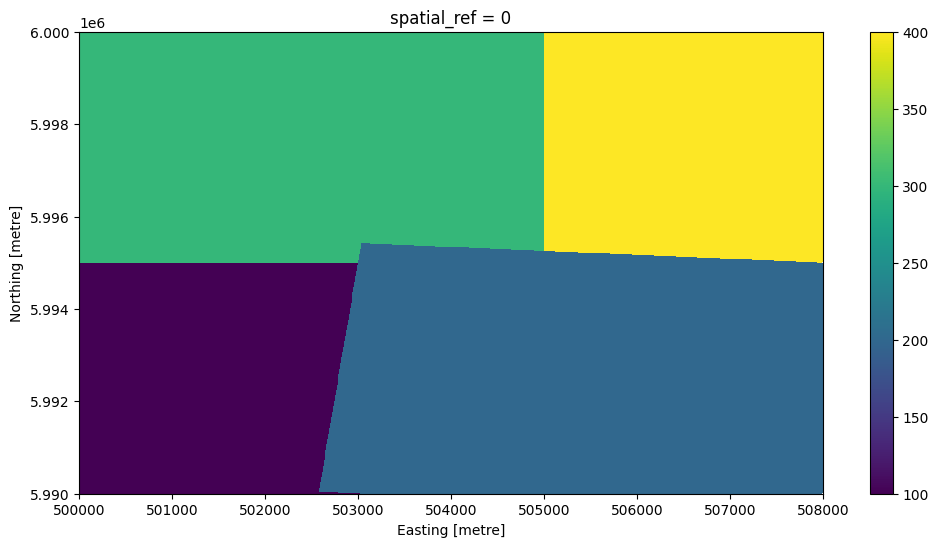

In [7]:
da.plot(figsize=(12, 6), cmap="viridis", add_colorbar=True);

## 6. Materialize to Zarr and read back

Write the merged result to a new Zarr store with convention metadata, then read it back
to verify the round-trip.

In [8]:
output_store = zarr.storage.MemoryStore()
to_zarr(result_arr, result_spatial, result_proj, output_store, path="mosaic")

out_root = zarr.open_group(output_store, mode="r")
out_arr = out_root["mosaic"]
out_spatial = read_spatial(out_arr)
out_proj = read_proj(out_arr)

print(f"Output shape:     {out_arr.shape}")
print(f"Output CRS:       {out_proj.code}")
print(f"Output bbox:      {out_spatial.bbox}")
print(f"Output transform: {out_spatial.transform}")

# Show zarr_conventions metadata written by zarr-cm
conventions = out_arr.attrs.get("zarr_conventions", [])
if conventions:
    print(f"\nzarr_conventions: {len(conventions)} registered")
    for conv in conventions:
        print(f"  - {conv['name']}: {conv['spec_url']}")

Output shape:     (1000, 800)
Output CRS:       EPSG:32618
Output bbox:      (500000.0, 5990000.0, 508000.0, 6000000.0)
Output transform: (10.0, 0.0, 500000.0, 0.0, -10.0, 6000000.0)

zarr_conventions: 2 registered
  - spatial:: https://github.com/zarr-conventions/spatial/blob/v1/README.md
  - proj:: https://github.com/zarr-experimental/geo-proj/blob/v1/README.md


## 7. Per-source visualization

Plot each source tile's contribution individually. The four fill values (100, 200, 300, 400)
correspond to the four quadrants of the mosaic. NaN regions are where a tile doesn't cover
the target grid.

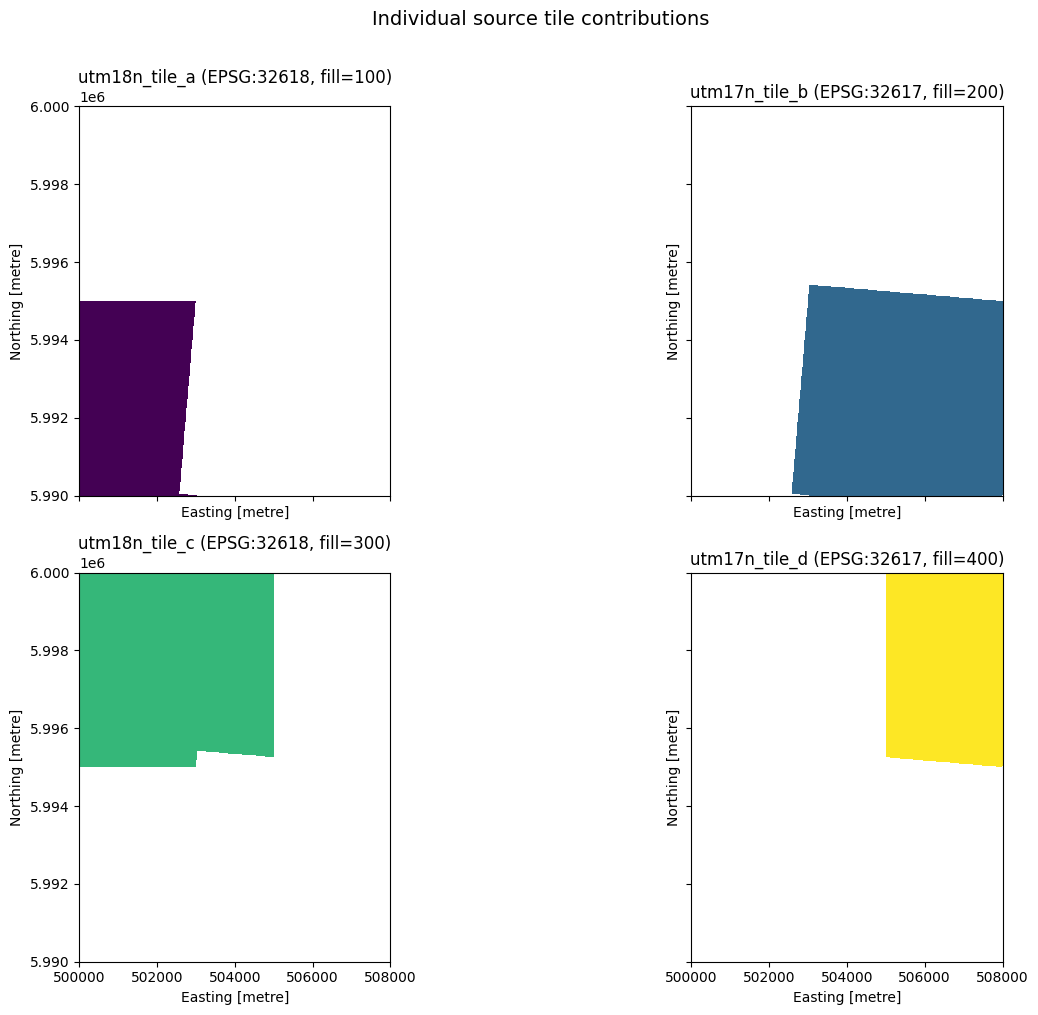

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

tiles = [
    (100.0, "utm18n_tile_a (EPSG:32618, fill=100)"),
    (200.0, "utm17n_tile_b (EPSG:32617, fill=200)"),
    (300.0, "utm18n_tile_c (EPSG:32618, fill=300)"),
    (400.0, "utm17n_tile_d (EPSG:32617, fill=400)"),
]

for ax, (fill_val, title) in zip(axes.flat, tiles):
    mask = xr.where(da == fill_val, da, np.nan)
    mask.plot(ax=ax, cmap="viridis", vmin=100, vmax=400, add_colorbar=False)
    ax.set_title(title)
    ax.set_aspect("equal")

fig.suptitle("Individual source tile contributions", fontsize=14, y=1.01)
fig.tight_layout();

## 8. Summary statistics

In [10]:
total_pixels = da.size
valid_pixels = int(da.count())
nan_pixels = total_pixels - valid_pixels
unique_vals = np.unique(da.values[~np.isnan(da.values)])

print(f"Total pixels:  {total_pixels:,}")
print(f"Valid pixels:  {valid_pixels:,}")
print(f"NaN pixels:    {nan_pixels:,}")
print(f"Coverage:      {valid_pixels / total_pixels:.1%}")
print(f"Unique values: {unique_vals}")

Total pixels:  800,000
Valid pixels:  799,996
NaN pixels:    4
Coverage:      100.0%
Unique values: [100. 200. 300. 400.]
